# Practica 05 : Generación de Dataset de Pacientes con indicadores para el cálculo de riesgo de Infarto Cardíaco en Puebla


**Programa de Estudios**: Ingenieria en Desarollo y Gestion de Software \
**Asignatura:** Extraccion de Conocimiento en Base de Datos\
**Docente**: M.T.I Marco A. Ramirez Hernandez\
**Periodo**: Mayo - Agosto 2026

### Unidad 2 : Preparacion de los Datos

**Nombre del Estudiante**: Derek Sesni Carreño \
**Matricula**: 230892\
**Grado y Grupo**: 9A° IDGS

---

### 1 - Importacion de librerias

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

### 2 - Cargar el Dataset

In [6]:
import os

try:
    df = pd.read_csv("pacientes_puebla.csv")
except FileNotFoundError:
    cwd = os.getcwd()
    raise FileNotFoundError(f"'pacientes_puebla.csv' not found. Current working directory: {cwd}. Place the file there or provide the correct path.")

df.head()

,id_paciente,edad,sexo,peso_kg,estatura_m,imc,presion_sistolica,presion_diastolica,frecuencia_cardiaca,glucosa,...,trigliceridos,oxigenacion,fumador,diabetes,hipertension,actividad_fisica,antecedente_familiar,latitud,longitud,riesgo
0,1,32,Masculino,104.3,1.57,42.31,107,107,68,243,...,339,91,No,No,No,Media,Sí,18.924842,-98.375769,Medio
1,2,22,Masculino,52.5,1.57,21.30,167,61,80,236,...,339,96,No,Sí,No,Baja,Sí,19.013595,-98.234244,Alto
2,3,53,Masculino,105.7,1.53,45.15,144,81,90,109,...,232,91,No,No,No,Alta,No,19.015717,-98.250844,Medio
3,4,30,Femenino,112.8,1.75,36.83,95,106,113,207,...,253,91,No,No,No,Alta,No,19.031737,-98.296845,Medio
4,5,64,Masculino,101.4,1.47,46.92,119,109,92,90,...,111,96,No,Sí,Sí,Baja,No,19.005385,-98.149454,Alto


### 3 - Verificar las dimensiones del dataset

In [7]:
df.shape

(5000, 21)

El dataset si esta conformado por 5000 pacientes

### 4 - Ver nombre de las columnas

In [8]:
list(df.columns)

['id_paciente',
 'edad',
 'sexo',
 'peso_kg',
 'estatura_m',
 'imc',
 'presion_sistolica',
 'presion_diastolica',
 'frecuencia_cardiaca',
 'glucosa',
 'colesterol',
 'trigliceridos',
 'oxigenacion',
 'fumador',
 'diabetes',
 'hipertension',
 'actividad_fisica',
 'antecedente_familiar',
 'latitud',
 'longitud',
 'riesgo']

Validar nombres de columnas

### 5 -  Verificar tipo de datos

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_paciente           5000 non-null   int64  
 1   edad                  5000 non-null   int64  
 2   sexo                  5000 non-null   object 
 3   peso_kg               5000 non-null   float64
 4   estatura_m            5000 non-null   float64
 5   imc                   5000 non-null   float64
 6   presion_sistolica     5000 non-null   int64  
 7   presion_diastolica    5000 non-null   int64  
 8   frecuencia_cardiaca   5000 non-null   int64  
 9   glucosa               5000 non-null   int64  
 10  colesterol            5000 non-null   int64  
 11  trigliceridos         5000 non-null   int64  
 12  oxigenacion           5000 non-null   int64  
 13  fumador               5000 non-null   object 
 14  diabetes              5000 non-null   object 
 15  hipertension         

### 6 - Buscar Valores nulos

In [11]:
df.isnull().sum()

id_paciente             0
edad                    0
sexo                    0
peso_kg                 0
estatura_m              0
imc                     0
presion_sistolica       0
presion_diastolica      0
frecuencia_cardiaca     0
glucosa                 0
colesterol              0
trigliceridos           0
oxigenacion             0
fumador                 0
diabetes                0
hipertension            0
actividad_fisica        0
antecedente_familiar    0
latitud                 0
longitud                0
riesgo                  0
dtype: int64

Al devolver 0 en todos los campos, no existen valores nulos

### 7 - Evitar datos duplicados

In [12]:
df.duplicated().sum()

np.int64(0)

No existen registros duplicados.

### 8 - Validar rangos clinicos

In [13]:
df.describe()

,id_paciente,edad,peso_kg,estatura_m,imc,presion_sistolica,presion_diastolica,frecuencia_cardiaca,glucosa,colesterol,trigliceridos,oxigenacion,latitud,longitud
count,5000.000000,5000.00000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,53.85880,84.83310,1.698238,30.076168,140.389400,85.089200,87.661800,159.796400,224.760200,203.123800,94.997800,19.129237,-98.059777
std,1443.520003,21.01051,23.25215,0.144134,9.843522,28.907489,14.564782,19.102115,52.318953,61.309465,84.355057,3.173548,0.454664,0.353465
min,1.000000,18.00000,45.00000,1.450000,12.190000,90.000000,60.000000,55.000000,70.000000,120.000000,60.000000,90.000000,18.290662,-98.610077
25%,1250.750000,36.00000,64.27500,1.570000,22.157500,115.000000,73.000000,71.000000,114.000000,171.000000,129.750000,92.000000,18.946223,-98.291826
50%,2500.500000,54.00000,84.80000,1.700000,29.295000,141.000000,85.000000,88.000000,161.000000,225.000000,202.000000,95.000000,19.047576,-98.180879
75%,3750.250000,72.00000,105.00000,1.820000,36.830000,166.000000,98.000000,104.000000,205.000000,278.000000,276.000000,98.000000,19.185962,-97.934360
max,5000.000000,90.00000,125.00000,1.950000,59.360000,190.000000,110.000000,120.000000,250.000000,330.000000,350.000000,100.000000,20.418500,-97.166981


### 9 -  Validar latitud y longitud

In [14]:
df[['latitud','longitud']].describe()

,latitud,longitud
count,5000.000000,5000.000000
mean,19.129237,-98.059777
std,0.454664,0.353465
min,18.290662,-98.610077
25%,18.946223,-98.291826
50%,19.047576,-98.180879
75%,19.185962,-97.934360
max,20.418500,-97.166981


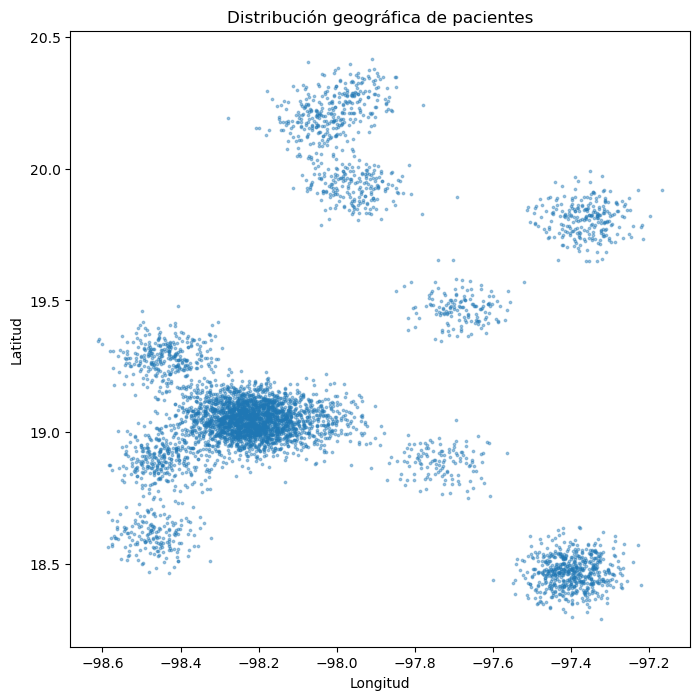

In [15]:
plt.figure(figsize=(8,8))

plt.scatter(
    df["longitud"],
    df["latitud"],
    s=3,
    alpha=0.4
)

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Distribución geográfica de pacientes")

plt.show()

### 11 - Limpieza básica de dataset

In [16]:
df = df.drop_duplicates()

df = df.dropna()

### 11 - Estadística descriptiva

In [17]:
df.describe()

,id_paciente,edad,peso_kg,estatura_m,imc,presion_sistolica,presion_diastolica,frecuencia_cardiaca,glucosa,colesterol,trigliceridos,oxigenacion,latitud,longitud
count,5000.000000,5000.00000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,53.85880,84.83310,1.698238,30.076168,140.389400,85.089200,87.661800,159.796400,224.760200,203.123800,94.997800,19.129237,-98.059777
std,1443.520003,21.01051,23.25215,0.144134,9.843522,28.907489,14.564782,19.102115,52.318953,61.309465,84.355057,3.173548,0.454664,0.353465
min,1.000000,18.00000,45.00000,1.450000,12.190000,90.000000,60.000000,55.000000,70.000000,120.000000,60.000000,90.000000,18.290662,-98.610077
25%,1250.750000,36.00000,64.27500,1.570000,22.157500,115.000000,73.000000,71.000000,114.000000,171.000000,129.750000,92.000000,18.946223,-98.291826
50%,2500.500000,54.00000,84.80000,1.700000,29.295000,141.000000,85.000000,88.000000,161.000000,225.000000,202.000000,95.000000,19.047576,-98.180879
75%,3750.250000,72.00000,105.00000,1.820000,36.830000,166.000000,98.000000,104.000000,205.000000,278.000000,276.000000,98.000000,19.185962,-97.934360
max,5000.000000,90.00000,125.00000,1.950000,59.360000,190.000000,110.000000,120.000000,250.000000,330.000000,350.000000,100.000000,20.418500,-97.166981


### 12 - Historigramas

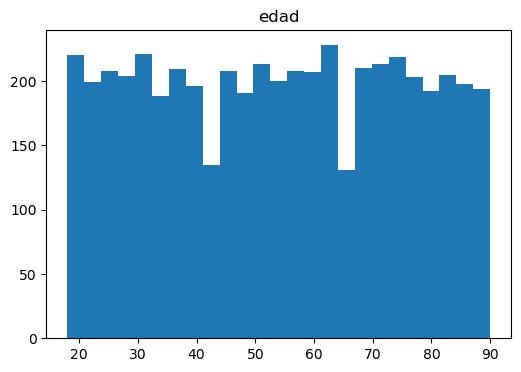

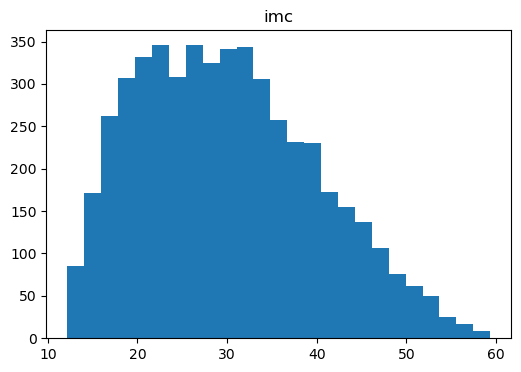

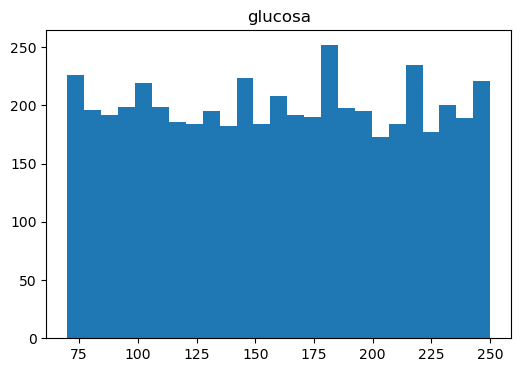

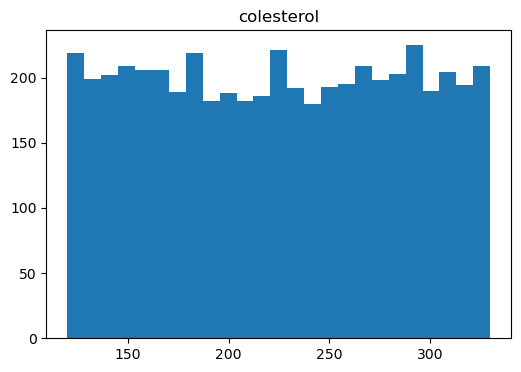

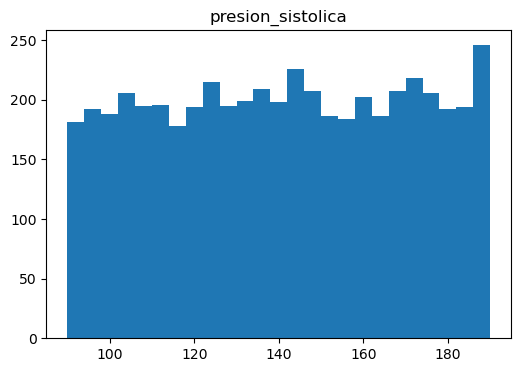

In [18]:
columnas = [
    "edad",
    "imc",
    "glucosa",
    "colesterol",
    "presion_sistolica"
]

for c in columnas:

    plt.figure(figsize=(6,4))

    plt.hist(df[c], bins=25)

    plt.title(c)

    plt.show()

### 13 - Distribución de riesgo

In [19]:
df["riesgo"].value_counts()

riesgo
Alto     2729
Medio    2145
Bajo      126
Name: count, dtype: int64

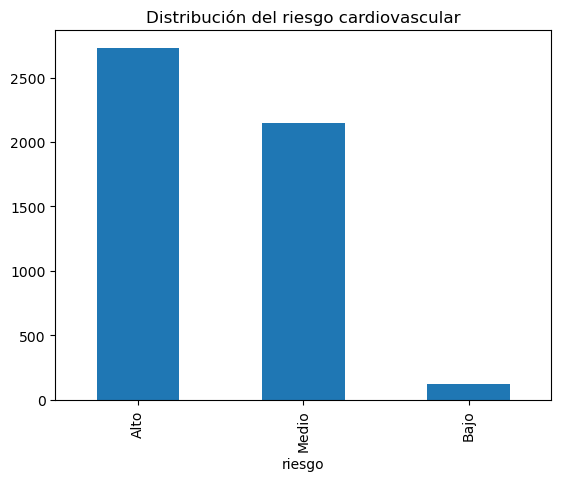

In [20]:
df["riesgo"].value_counts().plot(
    kind="bar"
)

plt.title("Distribución del riesgo cardiovascular")

plt.show()

### 14 - Correlación

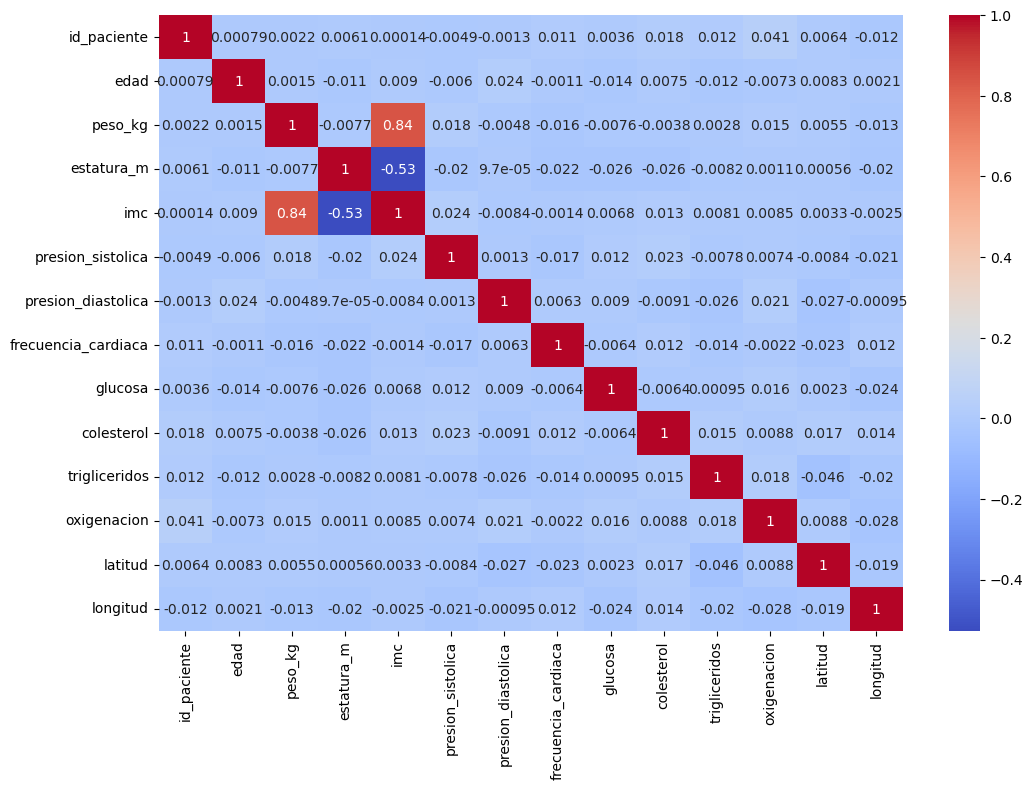

In [21]:
numericas = df.select_dtypes(include=np.number)

corr = numericas.corr()

plt.figure(figsize=(12,8))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.show()